# LIME and SHAP Tutorial on a Neural Network: Explaining Diabetes-Risk Predictions

**Dataset:** BRFSS 2015 diabetes health indicators (50/50 split) — predict `Diabetes_binary` from 21 health-indicator features.

**Outline:**
1. Load & explore the data
2. Pre-process (same split and scaling as `NeuNetworkDiab.ipynb`)
3. Train the neural network
4. Build the LIME explainer
5. Explain a single prediction with LIME
6. LIME: no-diabetes prediction for contrast
7. LIME: stability across random seeds
8. LIME: aggregate weights for a pseudo-global view
9. SHAP: single-instance and global explanations
10. LIME vs SHAP — side-by-side comparison

## 0. Install dependencies

In [1]:
%pip install lime shap torch scikit-learn pandas numpy matplotlib scipy --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Load the data

Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0



Target distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64
Number of features: 21
Train: (45242, 21)
Validation: (11311, 21)
Test: (14139, 21)
Epoch 01 | train loss: 0.5673 | val loss: 0.5091 | train acc: 0.714 | val acc: 0.751
Epoch 02 | train loss: 0.5088 | val loss: 0.5051 | train acc: 0.750 | val acc: 0.753
Epoch 03 | train loss: 0.5060 | val loss: 0.5044 | train acc: 0.751 | val acc: 0.751
Epoch 04 | train loss: 0.5044 | val loss: 0.5036 | train acc: 0.753 | val acc: 0.751
Epoch 05 | train loss: 0.5031 | val loss: 0.5023 | train acc: 0.753 | val acc: 0.752
Epoch 06 | train loss: 0.5018 | val loss: 0.5021 | train acc: 0.754 | val acc: 0.752
Epoch 07 | train loss: 0.5010 | val loss: 0.5018 | train acc: 0.756 | val acc: 0.751
Epoch 08 | train loss: 0.5002 | val loss: 0.5021 | train acc: 0.756 | val acc: 0.752
Epoch 09 | train loss: 0.5000 | val loss: 0.5021 | train acc: 0.757 | val acc: 0.753
Epoch 10 | train loss: 0.4993 | val loss: 0.5015 | train acc:

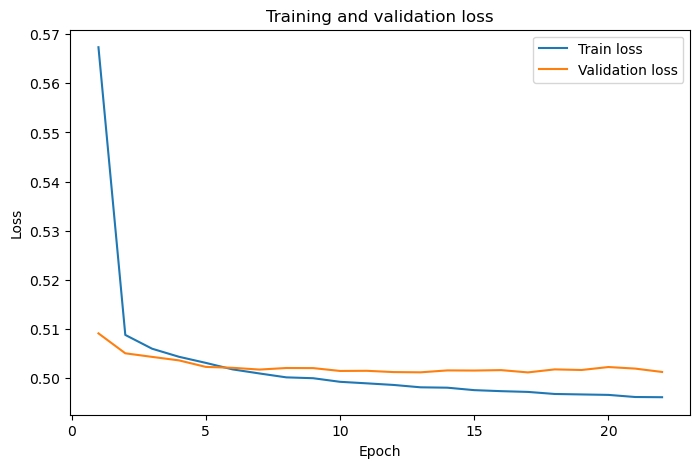

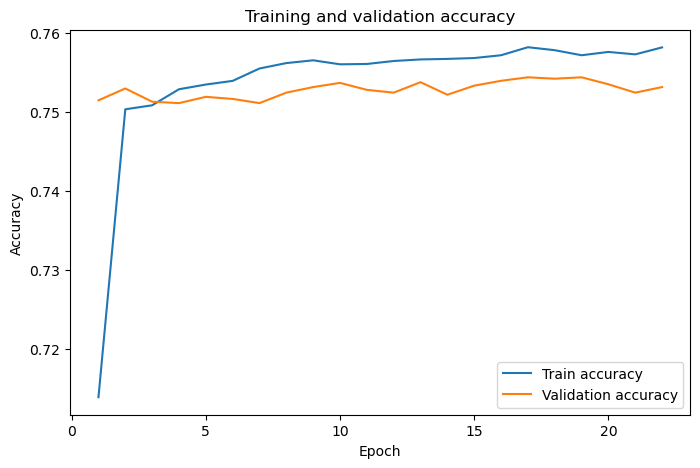

Test accuracy: 0.752
ROC-AUC:       0.829

Classification report:
              precision    recall  f1-score   support

         0.0      0.780     0.702     0.739      7070
         1.0      0.729     0.802     0.764      7069

    accuracy                          0.752     14139
   macro avg      0.754     0.752     0.751     14139
weighted avg      0.754     0.752     0.751     14139



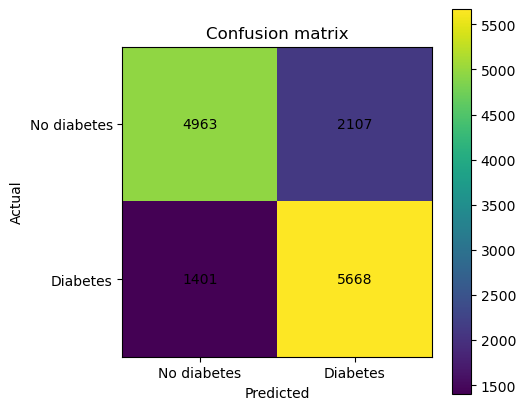

In [2]:
%run NeuNetworkDiab.ipynb

In [3]:
TARGET = 'Diabetes_binary'
FEATURE_COLS = [c for c in df.columns if c != TARGET]
class_names = ['No diabetes', 'Diabetes']
pos_label = 1   # index of the 'Diabetes' class

X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = df[TARGET].to_numpy(dtype=np.float32)

# Keep 20% completely separate for final testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Make a validation set from the remaining data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

# Standardize using training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print(f'Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}')

Train: (45242, 21), Validation: (11311, 21), Test: (14139, 21)


In [4]:
# Binary (0/1) features are treated as categorical by LIME
cat_cols = [c for c in FEATURE_COLS
            if set(np.unique(X_train_raw[:, FEATURE_COLS.index(c)])) <= {0.0, 1.0}]
num_cols = [c for c in FEATURE_COLS if c not in cat_cols]
cat_indices = [FEATURE_COLS.index(c) for c in cat_cols]

print('Categorical (binary):', cat_cols)
print('Numerical / ordinal :', num_cols)

Categorical (binary): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Numerical / ordinal : ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


In [5]:
def predict_proba(X_raw_array):
    X_scaled = scaler.transform(np.asarray(X_raw_array, dtype=np.float32)).astype(np.float32)
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(torch.from_numpy(X_scaled))).numpy().ravel()
    return np.column_stack([1 - p, p])

def predict(X_raw_array):
    return (predict_proba(X_raw_array)[:, 1] >= 0.5).astype(int)

test_proba = predict_proba(X_test_raw)[:, 1]
test_pred = predict(X_test_raw)

print(f'Test accuracy: {accuracy_score(y_test, test_pred):.3f}')
print(f'ROC-AUC:       {roc_auc_score(y_test, test_proba):.3f}\n')
print(classification_report(y_test, test_pred, target_names=class_names, digits=3))

Test accuracy: 0.752
ROC-AUC:       0.829

              precision    recall  f1-score   support

 No diabetes      0.780     0.702     0.739      7070
    Diabetes      0.729     0.802     0.764      7069

    accuracy                          0.752     14139
   macro avg      0.754     0.752     0.751     14139
weighted avg      0.754     0.752     0.751     14139



## 4. Build the LIME Explainer

`LimeTabularExplainer` needs:
- `training_data` — to learn the feature distributions for sampling (here: the **unscaled** training data)
- `feature_names` — column names
- `class_names` — label names
- `categorical_features` — indices of the binary columns
- `categorical_names` — mapping from encoded integer → readable string (for display)

In [6]:
import lime
import lime.lime_tabular

# Readable names for the binary features (0 = No, 1 = Yes; for Sex: 0 = female, 1 = male)
categorical_names = {}
for col in cat_cols:
    col_idx = FEATURE_COLS.index(col)
    categorical_names[col_idx] = ['Female', 'Male'] if col == 'Sex' else ['No', 'Yes']

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=FEATURE_COLS,
    class_names=class_names,
    categorical_features=cat_indices,
    categorical_names=categorical_names,
    mode='classification',
    random_state=42,
)
print('Explainer ready.')

Explainer ready.


## 5. Explain a single prediction

Pick one test instance and see *why* the network made its prediction.

In [7]:
# Pick the first test instance predicted as Diabetes
diabetes_mask = test_pred == pos_label
idx = np.where(diabetes_mask)[0][0]

instance = X_test_raw[idx]
pred_proba = predict_proba(instance.reshape(1, -1))[0]
pred_class = class_names[int(pred_proba.argmax())]

print(f'Explaining instance index {idx}')
print(f'Predicted class : {pred_class}   (true class: {class_names[int(y_test[idx])]})')
print(f'Class probabilities: {dict(zip(class_names, pred_proba.round(3)))}')
pd.Series(instance, index=FEATURE_COLS).to_frame('value').T

Explaining instance index 0
Predicted class : Diabetes   (true class: Diabetes)
Class probabilities: {'No diabetes': np.float32(0.071), 'Diabetes': np.float32(0.929)}


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
value,1.0,1.0,1.0,53.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,4.0,0.0,5.0,1.0,0.0,10.0,4.0,4.0


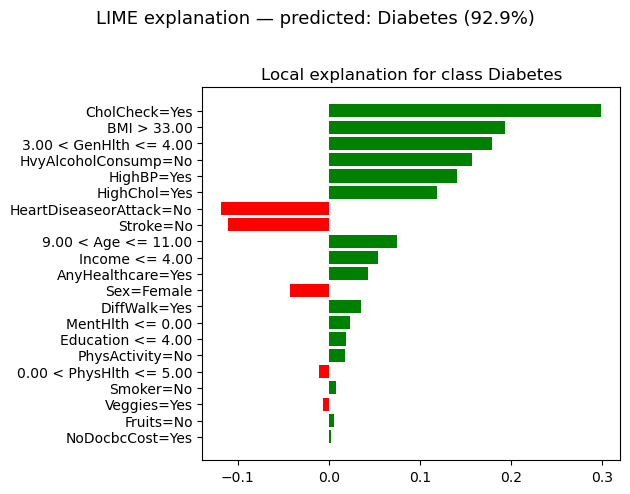

In [8]:
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=predict_proba,
    num_features=21,      # top-10 features in the explanation
    num_samples=5000,     # neighbourhood samples for the surrogate
)

fig = exp.as_pyplot_figure(label=pos_label)
fig.suptitle(f'LIME explanation — predicted: {pred_class} ({pred_proba.max():.1%})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Reading the plot
- **Green bars** push the prediction *toward* `Diabetes`; **red bars** push it *away*.
- Each bar is labelled with the feature condition for *this specific instance* (e.g. `HighBP=Yes`, `BMI > 33.00`).
- The x-axis is the weight of that feature in the local linear surrogate — not a global feature importance.

Vi ser at CholCheck vejes meget op 

In [9]:
# Also inspect the raw weights as a DataFrame
weights = exp.as_list(label=pos_label)
pd.DataFrame(weights, columns=['feature condition', 'LIME weight']).sort_values(
    'LIME weight', key=abs, ascending=False
)

,feature condition,LIME weight
0,CholCheck=Yes,0.298937
1,BMI > 33.00,0.193810
2,3.00 < GenHlth <= 4.00,0.178748
3,HvyAlcoholConsump=No,0.157435
4,HighBP=Yes,0.140667
5,HighChol=Yes,0.118364
6,HeartDiseaseorAttack=No,-0.117820
7,Stroke=No,-0.110315
8,9.00 < Age <= 11.00,0.075184
9,Income <= 4.00,0.054058


## 6. Explain a no-diabetes prediction for contrast

Explaining instance index 3 (true class: No diabetes)


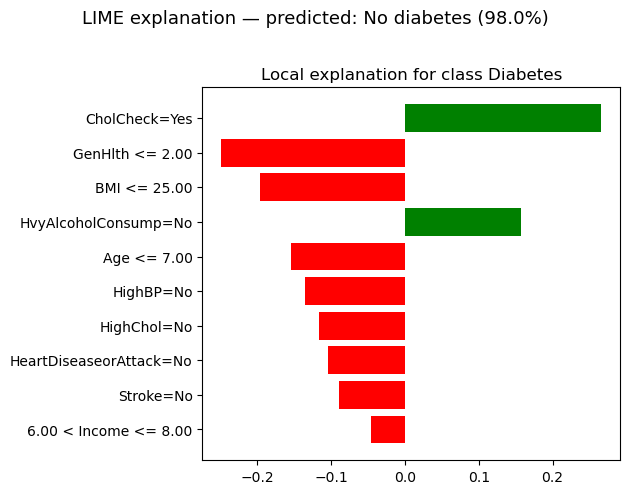

In [10]:
no_diabetes_mask = test_pred == 0
idx2 = np.where(no_diabetes_mask)[0][0]

instance2 = X_test_raw[idx2]
pred_proba2 = predict_proba(instance2.reshape(1, -1))[0]
pred_class2 = class_names[int(pred_proba2.argmax())]

exp2 = explainer.explain_instance(
    data_row=instance2,
    predict_fn=predict_proba,
    num_features=10,
    num_samples=5000,
)

print(f'Explaining instance index {idx2} (true class: {class_names[int(y_test[idx2])]})')
fig2 = exp2.as_pyplot_figure(label=pos_label)
fig2.suptitle(f'LIME explanation — predicted: {pred_class2} ({pred_proba2.max():.1%})',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Stability: same instance, different random seeds

LIME is stochastic — the neighbourhood is sampled randomly.
Let's check how stable the top features are across seeds.

In [11]:
from collections import Counter

N_RUNS = 10
top_k = 5

feature_counts = Counter()
for seed in range(N_RUNS):
    local_exp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_raw,
        feature_names=FEATURE_COLS,
        class_names=class_names,
        categorical_features=cat_indices,
        categorical_names=categorical_names,
        mode='classification',
        random_state=seed,
    ).explain_instance(
        data_row=instance,
        predict_fn=predict_proba,
        num_features=top_k,
        num_samples=5000,
    )
    for feat_name, _ in local_exp.as_list(label=pos_label):
        feature_counts[feat_name] += 1

stability_df = pd.DataFrame(
    feature_counts.most_common(), columns=['feature condition', f'appearances (/{N_RUNS})']
)
print(stability_df.to_string(index=False))

     feature condition  appearances (/10)
         CholCheck=Yes                 10
           BMI > 33.00                 10
3.00 < GenHlth <= 4.00                 10
            HighBP=Yes                 10
          HighChol=Yes                 10


Features appearing in all 10 runs are the most reliable parts of the explanation.
If a feature only appears in 2–3 runs, treat it with caution.

## 8. Aggregate LIME weights over many test instances

LIME is designed for *local* explanations, but averaging weights over many instances gives a rough global picture of which features matter most.

Note: we map weights to features with `exp.as_map()`, which returns `(feature index, weight)` pairs. Matching on the condition string would miss conditions that start with a number, such as `24.00 < BMI <= 27.00`.

In [12]:
N_EXPLAIN = 100  # increase for smoother averages (slower)
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_test_raw), size=N_EXPLAIN, replace=False)

weight_accumulator = {f: [] for f in FEATURE_COLS}

for i in sample_idx:
    e = explainer.explain_instance(
        data_row=X_test_raw[i],
        predict_fn=predict_proba,
        num_features=len(FEATURE_COLS),
        num_samples=1000,   # fewer samples → faster but noisier
    )
    for feat_idx, w in e.as_map()[pos_label]:
        weight_accumulator[FEATURE_COLS[feat_idx]].append(w)

mean_abs_weight = {
    f: np.mean(np.abs(ws)) for f, ws in weight_accumulator.items() if ws
}
global_df = pd.DataFrame(
    sorted(mean_abs_weight.items(), key=lambda x: x[1], reverse=True),
    columns=['feature', 'mean |LIME weight|']
)
print(global_df.to_string(index=False))

             feature  mean |LIME weight|
           CholCheck            0.263858
             GenHlth            0.164017
   HvyAlcoholConsump            0.152899
              HighBP            0.133896
                 BMI            0.114761
            HighChol            0.113904
HeartDiseaseorAttack            0.101967
                 Age            0.096791
              Stroke            0.092118
                 Sex            0.042280
            DiffWalk            0.039239
              Income            0.036267
       AnyHealthcare            0.030478
            MentHlth            0.024491
           Education            0.019229
         NoDocbcCost            0.015849
        PhysActivity            0.012231
             Veggies            0.011897
            PhysHlth            0.011735
              Smoker            0.010807
              Fruits            0.009866


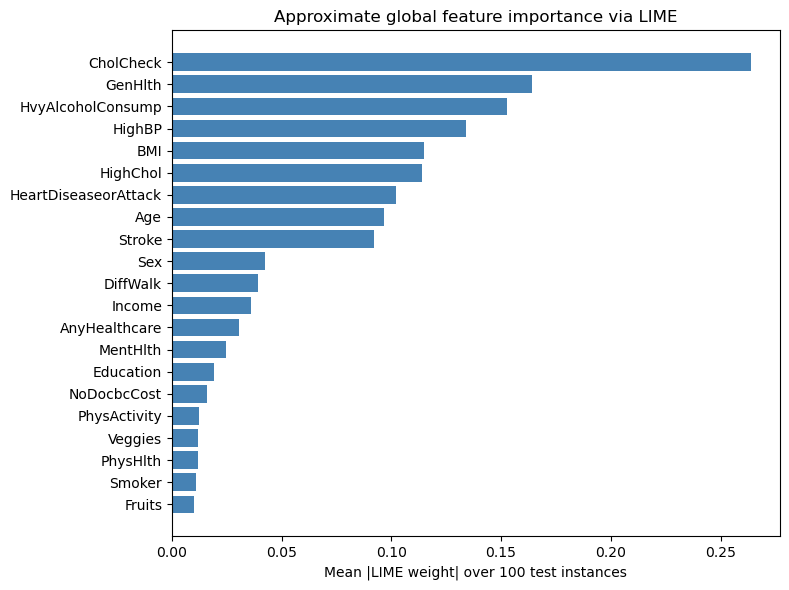

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(global_df['feature'][::-1], global_df['mean |LIME weight|'][::-1], color='steelblue')
ax.set_xlabel(f'Mean |LIME weight| over {N_EXPLAIN} test instances')
ax.set_title('Approximate global feature importance via LIME')
plt.tight_layout()
plt.show()

## 9. SHAP: interpreting the same model differently

**SHAP** (SHapley Additive exPlanations) computes each feature's contribution using Shapley values from cooperative game theory.

For a Random Forest we could use `TreeExplainer`. That does not work for a neural network, so we use **`shap.DeepExplainer`** (DeepSHAP):
- It combines Shapley values with **DeepLIFT**: contributions are propagated backwards through the layers, comparing each activation with its value for a set of **background** (reference) samples.
- It needs the model itself (PyTorch) and a background sample of inputs in the **scaled** space the network was trained on.
- To make SHAP values comparable with LIME (which explains probabilities), we append a `Sigmoid` so the explained output is `P(Diabetes)` instead of the logit.

**Key properties:**
- **Efficiency** — SHAP values sum to `f(x) − E[f(background)]`: the gap between the prediction and the average prediction on the background data.
- **Deterministic** — for a fixed background sample there is no sampling noise. But a different background gives a different baseline and (slightly) different values.
- **Approximate** — DeepSHAP is a fast approximation of Shapley values, not the exact values that TreeExplainer gives for trees.

In [14]:
import shap

# Explain the probability output: logits → sigmoid
prob_model = nn.Sequential(model, nn.Sigmoid()).eval()

# Background (reference) data: a random sample of the scaled training data
N_BACKGROUND = 200
rng_bg = np.random.default_rng(SEED)
bg_idx = rng_bg.choice(len(X_train), size=N_BACKGROUND, replace=False)
background = torch.tensor(X_train[bg_idx], dtype=torch.float32)

deep_explainer = shap.DeepExplainer(prob_model, background)

def to_2d(shap_vals):
    # DeepExplainer returns a list, a 2-D or a 3-D array depending on shap version
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    shap_vals = np.asarray(shap_vals)
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]
    return shap_vals

# SHAP values for a 500-instance sample of the test set
N_SHAP = 500
sv_pos_all = to_2d(deep_explainer.shap_values(torch.tensor(X_test[:N_SHAP])))

expected_val = float(np.ravel(np.asarray(deep_explainer.expected_value))[0])

print(f'SHAP values shape : {sv_pos_all.shape}')
print(f'Baseline (E[f(X)]): {expected_val:.4f}')

SHAP values shape : (500, 21)
Baseline (E[f(X)]): 0.5084


In [15]:
# Check the efficiency property: baseline + sum of SHAP values ≈ predicted probability
f_x = predict_proba(X_test_raw[:N_SHAP])[:, 1]
reconstructed = expected_val + sv_pos_all.sum(axis=1)
print(f'Max |f(x) − (E[f(X)] + Σ SHAP)| over {N_SHAP} instances: {np.max(np.abs(f_x - reconstructed)):.2e}')

Max |f(x) − (E[f(X)] + Σ SHAP)| over 500 instances: 1.86e-07


### 9.1 Single-instance explanations with SHAP

A **waterfall plot** starts from the baseline `E[f(X)]` and stacks each feature's contribution until it reaches the model's prediction `f(x)`.

- **Red bars** push the prediction *higher* (toward `Diabetes`).
- **Blue bars** push it *lower*.
- The bars sum to `f(x) − E[f(X)]`.

The values shown next to the feature names are the original (unscaled) feature values.
Compare these with the LIME bar charts in sections 5–6 — same instance, same model, different method.

Instance predicted as: Diabetes (92.9%)


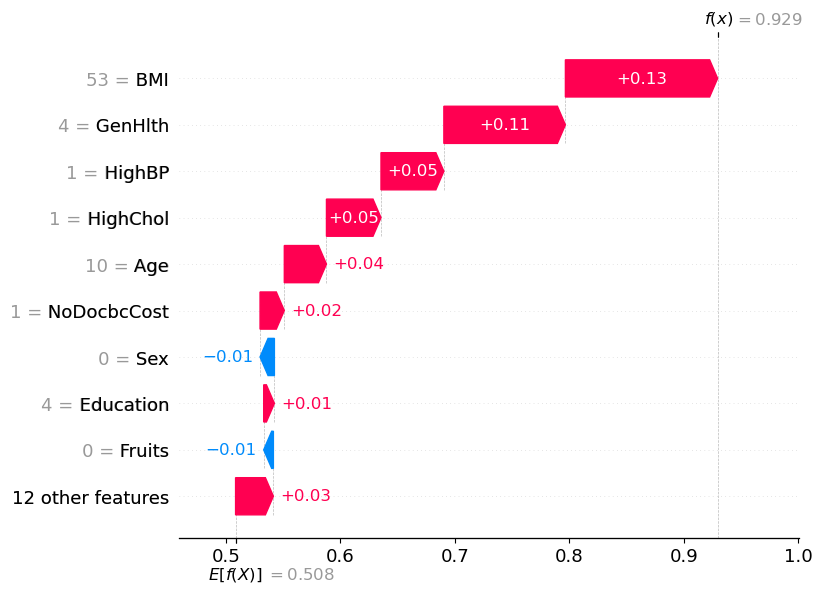

In [16]:
sv_hi_pos = to_2d(deep_explainer.shap_values(torch.tensor(X_test[idx:idx + 1])))[0]

shap_exp_hi = shap.Explanation(
    values=sv_hi_pos,
    base_values=expected_val,
    data=instance,              # unscaled values for display
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class} ({pred_proba.max():.1%})')
shap.plots.waterfall(shap_exp_hi)

Instance predicted as: No diabetes (98.0%)


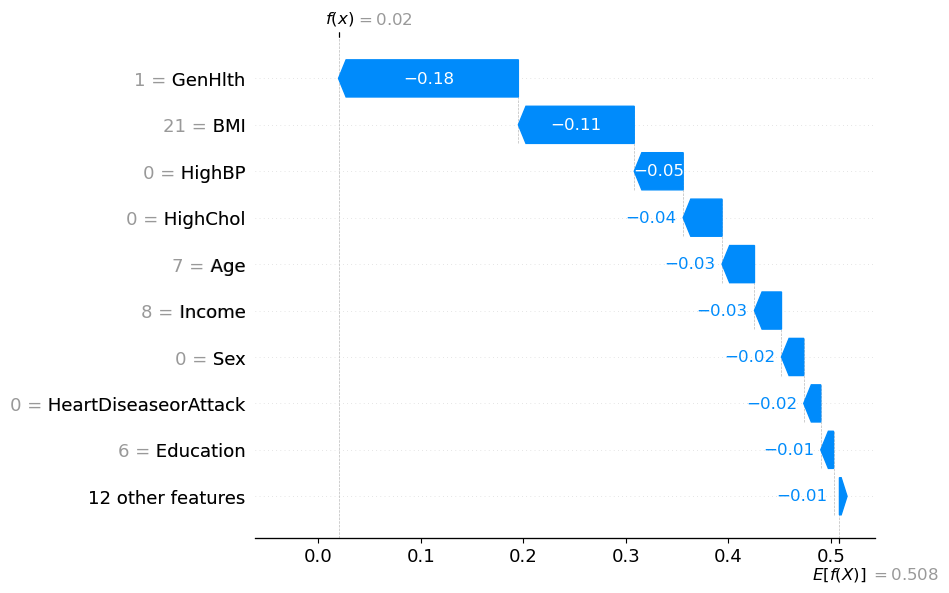

In [17]:
sv_lo_pos = to_2d(deep_explainer.shap_values(torch.tensor(X_test[idx2:idx2 + 1])))[0]

shap_exp_lo = shap.Explanation(
    values=sv_lo_pos,
    base_values=expected_val,
    data=instance2,
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class2} ({pred_proba2.max():.1%})')
shap.plots.waterfall(shap_exp_lo)

### 9.2 Global feature importance: the SHAP summary plot

Aggregating SHAP values over many instances gives a consistent global picture.

A **beeswarm plot** shows every instance as a dot. The x-axis is the SHAP value; colour encodes the raw feature value (red = high, blue = low). This reveals not just *which* features matter, but *how* their values relate to predictions — something a simple bar chart can't show.

/var/folders/z1/8_r86cf91979x2l05vvmpj4m0000gn/T/ipykernel_75997/256524370.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos_all, X_test_raw[:N_SHAP], feature_names=FEATURE_COLS)


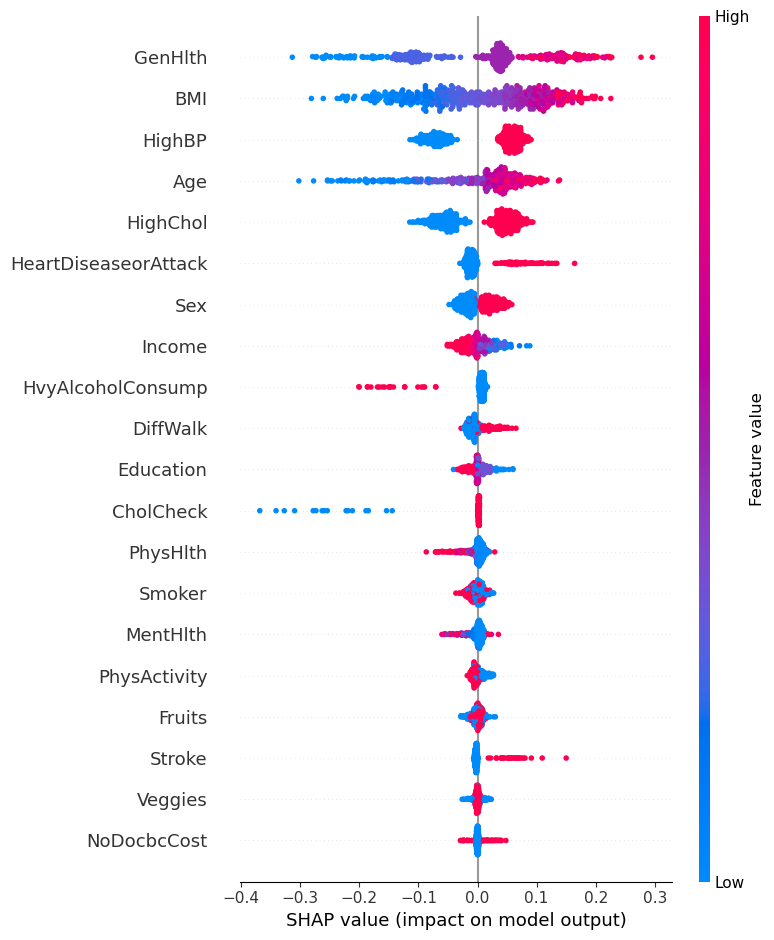

In [18]:
shap.summary_plot(sv_pos_all, X_test_raw[:N_SHAP], feature_names=FEATURE_COLS)

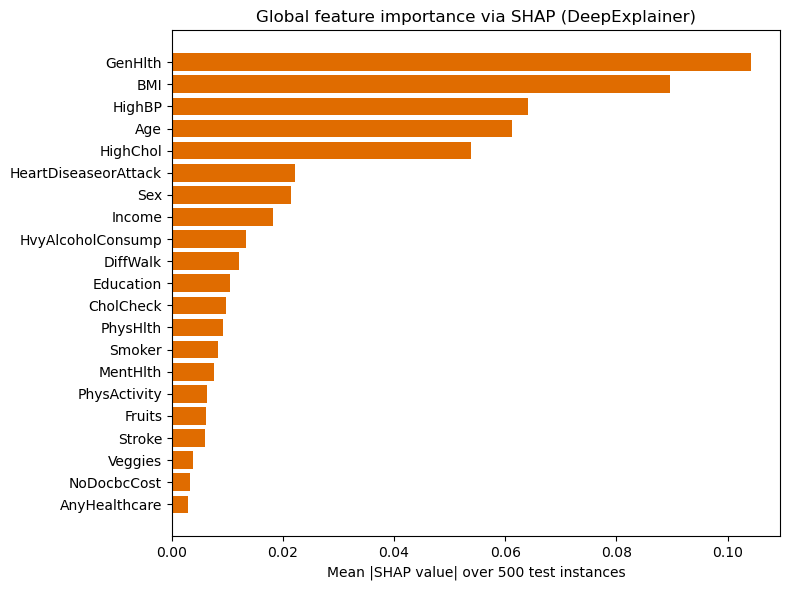

             feature  mean |SHAP|
             GenHlth     0.104231
                 BMI     0.089616
              HighBP     0.064166
                 Age     0.061201
            HighChol     0.053789
HeartDiseaseorAttack     0.022224
                 Sex     0.021419
              Income     0.018202
   HvyAlcoholConsump     0.013413
            DiffWalk     0.012076
           Education     0.010495
           CholCheck     0.009740
            PhysHlth     0.009149
              Smoker     0.008308
            MentHlth     0.007652
        PhysActivity     0.006308
              Fruits     0.006100
              Stroke     0.006020
             Veggies     0.003722
         NoDocbcCost     0.003264
       AnyHealthcare     0.002930


In [19]:
mean_abs_shap = np.mean(np.abs(sv_pos_all), axis=0)
shap_global_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean |SHAP|': mean_abs_shap,
}).sort_values('mean |SHAP|', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(shap_global_df['feature'][::-1], shap_global_df['mean |SHAP|'][::-1], color='#e06c00')
ax.set_xlabel(f'Mean |SHAP value| over {N_SHAP} test instances')
ax.set_title('Global feature importance via SHAP (DeepExplainer)')
plt.tight_layout()
plt.show()
print(shap_global_df.to_string(index=False))

## 10. LIME vs SHAP — side-by-side comparison

Both methods attribute a prediction to its features, but via different mechanisms. Here we compare them directly on **the same instance** and on the **same global ranking**.

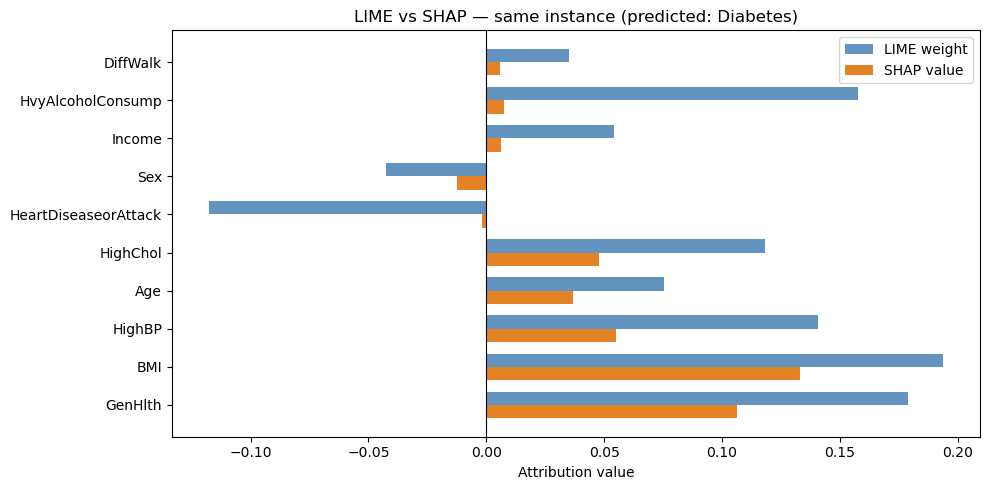

In [20]:
# LIME weights for the diabetes instance → map to feature names
lime_by_feature = {FEATURE_COLS[i]: w for i, w in exp.as_map()[pos_label]}

# SHAP values for the same instance
shap_by_feature = dict(zip(FEATURE_COLS, sv_hi_pos))

# Compare over the top-10 features by mean |SHAP| (global ranking)
top10 = shap_global_df['feature'].head(10).tolist()
lime_local = [lime_by_feature.get(f, 0) for f in top10]
shap_local = [shap_by_feature[f] for f in top10]

x = np.arange(len(top10))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(x + bar_w/2, lime_local, bar_w, label='LIME weight', color='steelblue', alpha=0.85)
ax.barh(x - bar_w/2, shap_local, bar_w, label='SHAP value', color='#e06c00', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Attribution value')
ax.set_title(f'LIME vs SHAP — same instance (predicted: {pred_class})')
ax.legend()
plt.tight_layout()
plt.show()

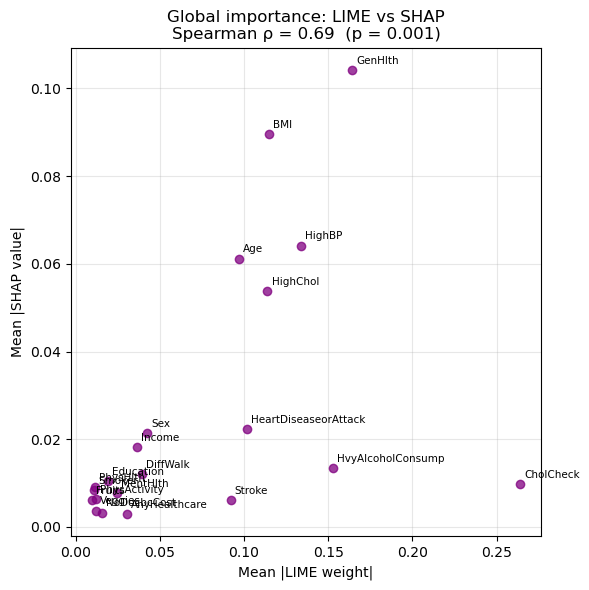

Spearman rank correlation: ρ = 0.688,  p = 0.0006


In [21]:
from scipy.stats import spearmanr

# Align global rankings by feature name
lime_series = global_df.set_index('feature')['mean |LIME weight|']
shap_series = shap_global_df.set_index('feature')['mean |SHAP|']
aligned = pd.DataFrame({'LIME': lime_series, 'SHAP': shap_series}).dropna()

rho, pval = spearmanr(aligned['LIME'], aligned['SHAP'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(aligned['LIME'], aligned['SHAP'], color='purple', alpha=0.75, zorder=3)
for feat, row in aligned.iterrows():
    ax.annotate(feat, (row['LIME'], row['SHAP']), fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Mean |LIME weight|')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title(f'Global importance: LIME vs SHAP\nSpearman ρ = {rho:.2f}  (p = {pval:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Spearman rank correlation: ρ = {rho:.3f},  p = {pval:.4f}')